<a href="https://colab.research.google.com/github/Pratham2664/FINC405_Project/blob/main/Final_Project_FIN405.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## FINAL PROJECT
**Pratham Patel**

****
## Introduction
Global supply chains are increasingly vulnerable to disruptions due to geopolitical, economic, and environmental factors. This project aims to identify key drivers of supply chain disruption risk and build predictive models to estimate disruption probability.

## Research Question
How can data science programming and machine learning techniques be used to predict supply chain disruptions, and which operational factors contribute most significantly to disruption risk?

## Objectives
- Explore and analyze supply chain disruption data using Python
- Develop reusable and modular data science programming workflows
- Visualize relationships between operational risk factors and disruptions
- Build machine learning models to predict supply chain disruptions
- Compare model performance using evaluation metrics
- Identify the most important variables contributing to disruption risk
- Demonstrate reproducible and organized data science programming practices

## Dataset

 [Global Supply Chain Risk & Logistics (2024-2026)](https://www.kaggle.com/datasets/nudratabbas/global-supply-chain-risk-and-logistics-2024-2026)

The dataset consists of 1000 shipment observations with both numerical and categorical variables. The target variable is Disruption_Occurred, indicating whether a disruption happened (1) or not (0).

Key features include:
- Lead Time (days)
- Geopolitical Risk Score
- Carrier Reliability Score
- Fuel Price Index
- Distance and Weight

These variables represent both operational and external risk factors.

## Methods

This project applies machine learning and data science programming techniques to predict supply chain disruptions using shipment-level operational and external risk data.

The dataset was explored and cleaned using Python and pandas. Key variables such as lead time, geopolitical risk score, carrier reliability score, fuel price index, distance, and shipment weight were used as predictor variables, while **Disruption_Occurred** was used as the target variable.

The data was divided into training and testing sets using an 80/20 split. Three machine learning classification models were implemented:
- Logistic Regression
- Random Forest
- Decision Tree

Reusable Python functions were developed for data loading, visualization, model training, and evaluation to improve code organization and reproducibility.

The models were evaluated using accuracy, confusion matrix, precision, recall, F1-score, and ROC-AUC analysis.

In [ ]:
# Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier

from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
    roc_curve,
    auc
)

In [ ]:
def load_data(file_path):

    df = pd.read_csv(file_path)

    return df

# Load dataset
df = load_data('/content/global_supply_chain_risk_2026 (1).csv')

# Preview data
df.head()

,Shipment_ID,Date,Origin_Port,Destination_Port,Transport_Mode,Product_Category,Distance_km,Weight_MT,Fuel_Price_Index,Geopolitical_Risk_Score,Weather_Condition,Carrier_Reliability_Score,Lead_Time_Days,Disruption_Occurred
0,SC-10000,2025-10-16,Singapore,Los Angeles,Rail,Textiles,5930.83,197.42,2.43,5.0,Hurricane,0.865,41.39,1
1,SC-10001,2024-04-24,Singapore,Shanghai,Rail,Automotive,14285.36,237.24,2.30,7.5,Storm,0.592,40.92,1
2,SC-10002,2024-01-26,Rotterdam,Los Angeles,Rail,Perishables,11113.91,427.42,1.78,5.6,Rain,0.673,11.54,0
3,SC-10003,2024-10-08,Busan,Hamburg,Rail,Electronics,9180.55,170.66,3.20,0.8,Hurricane,0.832,53.13,1
4,SC-10004,2024-09-07,Busan,Singapore,Air,Perishables,2762.27,434.96,2.77,1.9,Fog,0.741,0.50,1


Data Exploration



In [ ]:
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 14 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Shipment_ID                5000 non-null   object 
 1   Date                       5000 non-null   object 
 2   Origin_Port                5000 non-null   object 
 3   Destination_Port           5000 non-null   object 
 4   Transport_Mode             5000 non-null   object 
 5   Product_Category           5000 non-null   object 
 6   Distance_km                5000 non-null   float64
 7   Weight_MT                  5000 non-null   float64
 8   Fuel_Price_Index           5000 non-null   float64
 9   Geopolitical_Risk_Score    5000 non-null   float64
 10  Weather_Condition          5000 non-null   object 
 11  Carrier_Reliability_Score  5000 non-null   float64
 12  Lead_Time_Days             5000 non-null   float64
 13  Disruption_Occurred        5000 non-null   int64

,Distance_km,Weight_MT,Fuel_Price_Index,Geopolitical_Risk_Score,Carrier_Reliability_Score,Lead_Time_Days,Disruption_Occurred
count,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000
mean,7704.063888,246.252052,2.854552,5.076900,0.754387,19.355386,0.612600
std,4199.687885,142.522591,0.959533,2.877832,0.144363,31.405143,0.487205
min,500.170000,1.030000,1.200000,0.000000,0.500000,0.500000,0.000000
25%,4036.010000,124.330000,2.020000,2.600000,0.629000,2.110000,0.000000
50%,7750.125000,243.500000,2.840000,5.100000,0.757000,8.245000,1.000000
75%,11347.462500,366.955000,3.710000,7.500000,0.879000,21.207500,1.000000
max,14995.910000,499.750000,4.500000,10.000000,1.000000,236.390000,1.000000


## Visualization
**Distribution of Target**

In [ ]:
def plot_disruption_distribution(df):
    df['Disruption_Occurred'].value_counts().plot(kind='bar')
    plt.title("Disruption Distribution")
    plt.show()

The dataset shows a higher frequency of disruptions compared to non-disruptions, indicating that supply chain instability is a common occurrence in the observed data.

**Correlation Heatmap**

In [ ]:
def plot_correlation_heatmap(df):
    import seaborn as sns
    sns.heatmap(df.corr(numeric_only=True), annot=True)
    plt.title("Correlation Heatmap")
    plt.show()

Lead time and geopolitical risk show the strongest positive relationships with disruptions, suggesting that longer delivery durations and higher geopolitical instability significantly increase risk. Carrier reliability exhibits a negative relationship, indicating that more reliable carriers reduce disruption likelihood.

###Machine Learning Models

Three machine learning models are implemented:
- Logistic Regression
- Random Forest
- Decision Tree

Reusable functions are used to improve code organization and reproducibility.

<br>

**Model Training**

In [ ]:
def train_logistic_regression(X_train, y_train):

    model = LogisticRegression(max_iter=1000)

    model.fit(X_train, y_train)

    return model


def train_random_forest(X_train, y_train):

    model = RandomForestClassifier(
        n_estimators=100,
        random_state=42
    )

    model.fit(X_train, y_train)

    return model


def train_decision_tree(X_train, y_train):

    model = DecisionTreeClassifier(
        random_state=42,
        max_depth=5
    )

    model.fit(X_train, y_train)

    return model

**Evaluation function**

In [ ]:
def evaluate_model(model, X_test, y_test):

    predictions = model.predict(X_test)

    accuracy = accuracy_score(
        y_test,
        predictions
    )

    print("Accuracy:", accuracy)

    print("\nConfusion Matrix:")
    print(confusion_matrix(
        y_test,
        predictions
    ))

    print("\nClassification Report:")
    print(classification_report(
        y_test,
        predictions
    ))

    return accuracy

**Logistic Regression**

In [ ]:
print("LOGISTIC REGRESSION")

log_model = train_logistic_regression(
    X_train,
    y_train
)

log_acc = evaluate_model(
    log_model,
    X_test,
    y_test
)

# Coefficients
coef_df = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': log_model.coef_[0]
})

coef_df = coef_df.sort_values(
    by='Coefficient',
    ascending=False
)

print("\nCoefficient Table:")
print(coef_df)


LOGISTIC REGRESSION
Accuracy: 0.675

Confusion Matrix:
[[186 193]
 [132 489]]

Classification Report:
              precision    recall  f1-score   support

           0       0.58      0.49      0.53       379
           1       0.72      0.79      0.75       621

    accuracy                           0.68      1000
   macro avg       0.65      0.64      0.64      1000
weighted avg       0.67      0.68      0.67      1000


Coefficient Table:
                     Feature  Coefficient
1    Geopolitical_Risk_Score     0.160055
3             Lead_Time_Days     0.044984
5                  Weight_MT     0.000281
4                Distance_km    -0.000069
0           Fuel_Price_Index    -0.011054
2  Carrier_Reliability_Score    -1.199464


The Logistic Regression model achieved an accuracy of 67.5%, making it the highest-performing model in this analysis.

The model demonstrated strong performance in identifying disruption cases, achieving a recall score of 0.79 for disrupted shipments. This indicates that the model is effective at detecting high-risk shipments and potential operational disruptions.

The results also show that carrier reliability has a strong negative relationship with disruptions, meaning that reliable logistics providers significantly reduce disruption risk. Lead time and geopolitical risk showed positive relationships with disruptions, suggesting that longer delivery durations and external instability increase the probability of supply chain failures.

Overall, Logistic Regression provided strong interpretability and balanced predictive performance.

**Random Forest Model**

RANDOM FOREST
Accuracy: 0.668

Confusion Matrix:
[[198 181]
 [151 470]]

Classification Report:
              precision    recall  f1-score   support

           0       0.57      0.52      0.54       379
           1       0.72      0.76      0.74       621

    accuracy                           0.67      1000
   macro avg       0.64      0.64      0.64      1000
weighted avg       0.66      0.67      0.67      1000


Feature Importance:
Lead_Time_Days               0.249261
Distance_km                  0.162288
Geopolitical_Risk_Score      0.161063
Carrier_Reliability_Score    0.144911
Weight_MT                    0.143741
Fuel_Price_Index             0.138737
dtype: float64


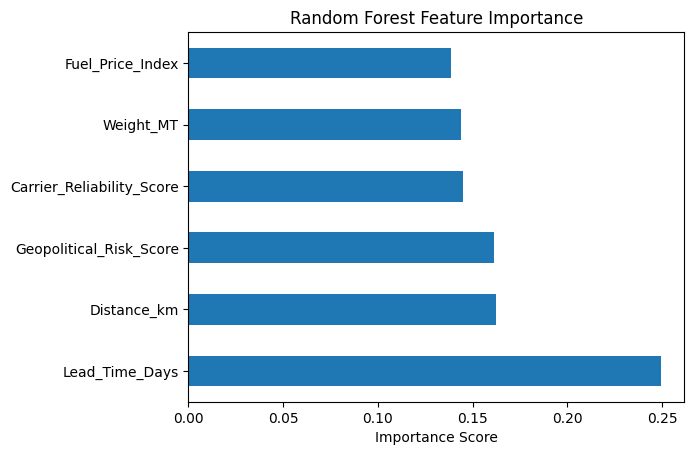

In [ ]:
print("RANDOM FOREST")

rf_model = train_random_forest(
    X_train,
    y_train
)

rf_acc = evaluate_model(
    rf_model,
    X_test,
    y_test
)

# Feature importance
importance = pd.Series(
    rf_model.feature_importances_,
    index=X.columns
)

importance = importance.sort_values(
    ascending=False
)

print("\nFeature Importance:")
print(importance)

# Plot feature importance
importance.plot(kind='barh')

plt.title("Random Forest Feature Importance")
plt.xlabel("Importance Score")

plt.show()


The Random Forest model achieved an accuracy of 66.8% and demonstrated strong predictive capability across multiple evaluation metrics.

Feature importance analysis identified lead time as the most significant predictor of disruptions, followed by distance, geopolitical risk, and carrier reliability. This suggests that operational efficiency and external instability play major roles in supply chain performance.

The Random Forest model achieved an ROC-AUC score of 0.72, indicating good discriminatory ability between disruption and non-disruption cases. The model performed particularly well in identifying disruption cases, making it useful for proactive risk management and operational planning.

Overall, Random Forest provided valuable nonlinear modeling and feature importance insights.

**Decision Tree**

In [ ]:
print("DECISION TREE")

dt_model = train_decision_tree(
    X_train,
    y_train
)

dt_acc = evaluate_model(
    dt_model,
    X_test,
    y_test
)

DECISION TREE
Accuracy: 0.647

Confusion Matrix:
[[228 151]
 [202 419]]

Classification Report:
              precision    recall  f1-score   support

           0       0.53      0.60      0.56       379
           1       0.74      0.67      0.70       621

    accuracy                           0.65      1000
   macro avg       0.63      0.64      0.63      1000
weighted avg       0.66      0.65      0.65      1000



The Decision Tree model achieved an accuracy of 64.7%, which was slightly lower than Logistic Regression and Random Forest.

Despite lower predictive performance, the Decision Tree model provided interpretable rule-based classifications that help explain how supply chain variables influence disruption outcomes.

The model demonstrated moderate capability in distinguishing disruption and non-disruption cases and highlighted the importance of operational factors such as lead time and carrier reliability.

Decision Trees are useful because they provide visual and interpretable decision-making structures that support understanding of risk patterns within supply chain systems.

**Model Comparison**

                 Model  Accuracy
0  Logistic Regression     0.675
1        Random Forest     0.668
2        Decision Tree     0.647


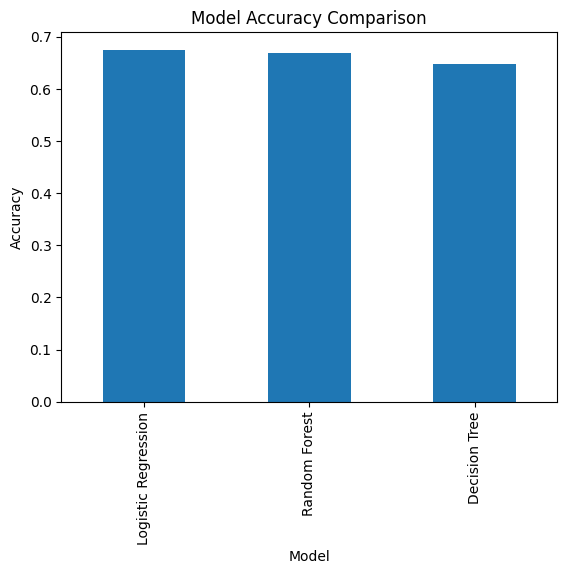

In [ ]:
comparison = pd.DataFrame({
    'Model': [
        'Logistic Regression',
        'Random Forest',
        'Decision Tree'
    ],
    'Accuracy': [
        log_acc,
        rf_acc,
        dt_acc
    ]
})

print(comparison)

comparison.plot(
    x='Model',
    y='Accuracy',
    kind='bar',
    legend=False
)

plt.title("Model Accuracy Comparison")
plt.ylabel("Accuracy")

plt.show()

The three machine learning models produced similar predictive performance, with Logistic Regression achieving the highest accuracy (67.5%), followed closely by Random Forest (66.8%) and Decision Tree (64.7%).

Although Random Forest and Decision Tree are capable of modeling nonlinear relationships, Logistic Regression slightly outperformed the other models on this dataset, suggesting that the relationships between the predictor variables and disruption risk are relatively structured and interpretable.

Each model provides different advantages:
- Logistic Regression offers strong interpretability
- Random Forest provides feature importance and nonlinear modeling
- Decision Tree provides simple and interpretable classification rules

Overall, using multiple machine learning models provides a comprehensive understanding of supply chain disruption risk.

**ROC Curve**

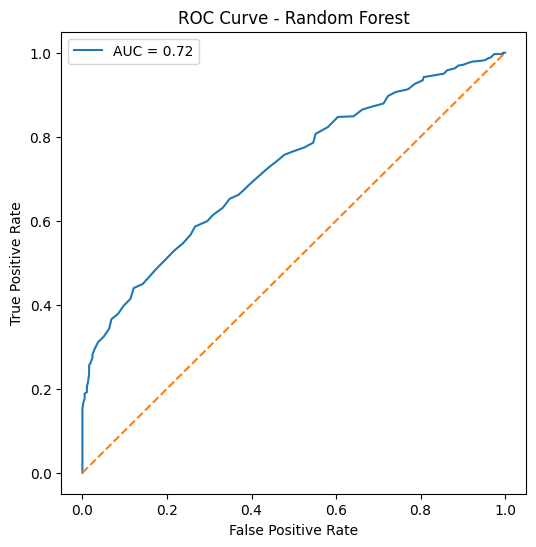

In [ ]:
from sklearn.metrics import roc_curve, auc

# Probabilities
y_probs = rf_model.predict_proba(X_test)[:, 1]

# ROC values
fpr, tpr, thresholds = roc_curve(y_test, y_probs)

roc_auc = auc(fpr, tpr)

# Plot
plt.figure(figsize=(6,6))

plt.plot(fpr, tpr, label=f'AUC = {roc_auc:.2f}')
plt.plot([0,1], [0,1], linestyle='--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Random Forest")
plt.legend()

plt.show()

The ROC curve evaluates the classification performance of the Random Forest model across different probability thresholds. The model achieved an Area Under the Curve (AUC) score of 0.72, indicating good ability to distinguish between disruption and non-disruption cases. Since an AUC value above 0.70 is generally considered acceptable in classification tasks, the results demonstrate that the model performs meaningfully better than random guessing.

This suggests that the Random Forest model is reasonably effective for identifying high-risk supply chain disruptions and can support proactive operational decision-making.

#### **Business Recommendations**

Based on the results of the machine learning models, organizations should focus on reducing lead times and improving carrier reliability to minimize disruption risk.

Since geopolitical instability was identified as a significant disruption driver, companies should diversify suppliers, transportation routes, and sourcing regions to reduce dependence on high-risk areas.

The models also demonstrate the value of predictive analytics in supply chain management. Companies can use machine learning systems to identify high-risk shipments early and implement proactive strategies to reduce delays, operational losses, and service interruptions.

Overall, improving operational efficiency and applying predictive risk monitoring can significantly strengthen supply chain resilience.

<br>

#### **Final Interpretation**

This project demonstrates how data science programming and machine learning techniques can be applied to predict supply chain disruptions and identify critical operational risk factors.

Multiple machine learning models were implemented and evaluated, including Logistic Regression, Random Forest, and Decision Tree. Logistic Regression achieved the highest predictive accuracy, while Random Forest provided strong feature importance analysis and nonlinear modeling capability.

The results consistently identified lead time, geopolitical risk, and carrier reliability as major contributors to disruption risk. Longer lead times and higher geopolitical instability increase disruption probability, while reliable logistics providers reduce operational risk.

The project also demonstrates the importance of modular programming, reusable workflows, visualization, and reproducible data science practices in solving real-world business problems.

Overall, the findings highlight how machine learning can support data-driven decision-making and improve supply chain risk management strategies.

## Execution Block

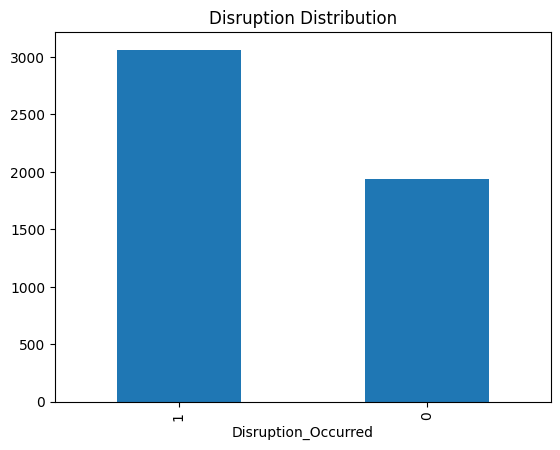

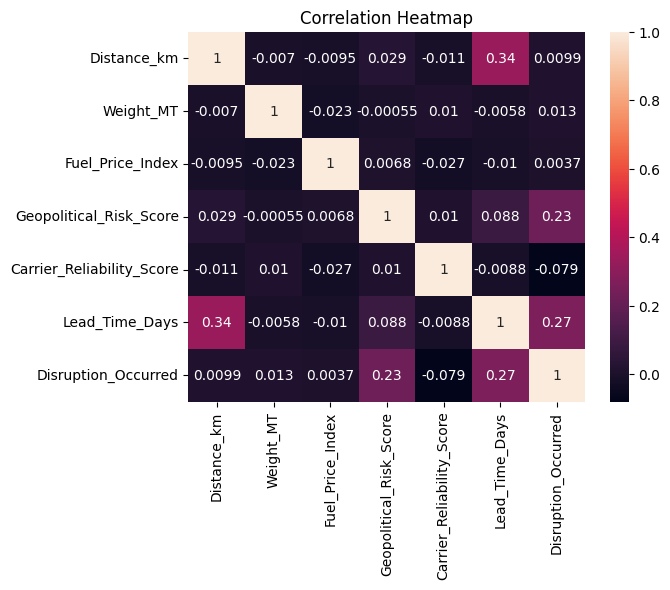


LOGISTIC REGRESSION
Accuracy: 0.675

Confusion Matrix:
[[186 193]
 [132 489]]

Classification Report:
              precision    recall  f1-score   support

           0       0.58      0.49      0.53       379
           1       0.72      0.79      0.75       621

    accuracy                           0.68      1000
   macro avg       0.65      0.64      0.64      1000
weighted avg       0.67      0.68      0.67      1000


RANDOM FOREST
Accuracy: 0.668

Confusion Matrix:
[[198 181]
 [151 470]]

Classification Report:
              precision    recall  f1-score   support

           0       0.57      0.52      0.54       379
           1       0.72      0.76      0.74       621

    accuracy                           0.67      1000
   macro avg       0.64      0.64      0.64      1000
weighted avg       0.66      0.67      0.67      1000


DECISION TREE
Accuracy: 0.647

Confusion Matrix:
[[228 151]
 [202 419]]

Classification Report:
              precision    recall  f1-score   sup

In [ ]:
def main():

    # Load data
    df = load_data('/content/global_supply_chain_risk_2026 (1).csv')

    # Visualizations
    plot_disruption_distribution(df)

    plot_correlation_heatmap(df)

    # Feature selection
    X = df[['Fuel_Price_Index',
            'Geopolitical_Risk_Score',
            'Carrier_Reliability_Score',
            'Lead_Time_Days',
            'Distance_km',
            'Weight_MT']]

    y = df['Disruption_Occurred']

    # Split data
    X_train, X_test, y_train, y_test = train_test_split(
        X,
        y,
        test_size=0.2,
        random_state=42
    )

    # Train models
    log_model = train_logistic_regression(X_train, y_train)

    rf_model = train_random_forest(X_train, y_train)

    dt_model = train_decision_tree(X_train, y_train)

    # Evaluate
    print("\nLOGISTIC REGRESSION")
    evaluate_model(log_model, X_test, y_test)

    print("\nRANDOM FOREST")
    evaluate_model(rf_model, X_test, y_test)

    print("\nDECISION TREE")
    evaluate_model(dt_model, X_test, y_test)


if __name__ == "__main__":
    main()